# Ego4D - Object Detection

Problem 1: Given a frame from an egocentric video, detect the target object in the vision query

e.g
-  "Target object": "Mr krips jar"
- Clip provided: Egocentric view of a person shopping in a grocery aisle


## Models
| Model | Architecture | Pretrained On |
|-------|-------------|---------------|
| YOLOv8s | Anchor-free, multi-scale CNN | COCO |
| Deformable DETR | Transformer + deformable attention | COCO |


**Evaluation protocol**
- Zero-shot: pretrained COCO weights, all predictions treated as class-agnostic

- Fine-tuned: trained on eGO4d response track frames

- Metrics: mAP@0.5, mAP@0.5:0.95

**Key findings from EDA informing the object detection problem formulation**

1. Median normalized object area within a frame: 1.9% of the frame

2. Frame resolution: 720 x 540 - 2x downsclaed from annotation space

3. 246,206 labeled detection frames across train and validation splits

4. Single class (object-agnostic detection) - Class-agnostic object detection (CA-OD) is a computer vision approach that localizes all objects within an image by drawing bounding boxes without identifying their specific categories (e.g., detecting "an object" rather than "a car" or "a dog"). This method improves generalization to unseen objects, reduces dependence on fully labeled datasets, and powers open-world detection

## Imports & Configurations

In [ ]:
!pip install ultralytics transformers torch torchvision google-cloud-storage pycocotools tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.2 MB/s eta 0:00:00


In [ ]:
import json
import os
import shutil
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm.notebook import tqdm
from google.cloud import storage
from ultralytics import YOLO
from tqdm.notebook import tqdm

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
#GCS configuration
BUCKET_NAME = "egorecall-data"

#Local paths
DATA_DIR = Path("/content/egorecall_detection")
RESULTS_DIR = Path("/content/results/detection")

DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:
# Training configurations
YOLO_MODEL = "yolov8s.pt"
DETR_MODEL = "SenseTime/deformable-detr"
IMG_SIZE = 640 #YOLOv8 input size
YOLO_EPOCHS = 50
DETR_EPOCHS = 30
YOLO_BATCH_SIZE = 16
DETR_BATCH_SIZE = 4 #Deformable DETER is memory heavy
NUM_CLASSES = 1
CONF_THRESHOLD = 0.25 #0.5 - zero-shot inference confidence
IOU_THRESHOLD = 0.5

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## GCS Authentication

In [ ]:
from google.colab import auth
auth.authenticate_user()

gcs_client = storage.Client()
bucket = gcs_client.bucket(BUCKET_NAME)
print(f"Connected to gs://{BUCKET_NAME}")

Connected to gs://egorecall-data


## Sync Detection Frames from GCS to Local Colab

Estimated size is 19GB, which fits comfortably within Colab Pro's 200GB disk

In [ ]:
result = subprocess.run(["df", "-h", "/content"], capture_output=True, text=True)
print(result.stdout)

Filesystem      Size  Used Avail Use% Mounted on
overlay         236G   44G  193G  19% /



In [ ]:
# Create directories first
(DATA_DIR / "train" / "images").mkdir(parents=True, exist_ok=True)
(DATA_DIR / "val"   / "images").mkdir(parents=True, exist_ok=True)
(DATA_DIR / "train" / "labels").mkdir(parents=True, exist_ok=True)
(DATA_DIR / "val"   / "labels").mkdir(parents=True, exist_ok=True)
print("Directories created.")

Directories created.


## Uncomment and Run this section only once -> you should have at least 30GB of RAM on colab to run this

In [ ]:
!gsutil cp gs://egorecall-data/processed/lbl_val.tar.gz   /tmp/
!tar -xzf /tmp/lbl_val.tar.gz   -C /content/egorecall_detection/val/labels/   --strip-components=2

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://egorecall-data/processed/lbl_val.tar.gz...
/ [1 files][  2.1 MiB/  2.1 MiB]                                                
Operation completed over 1 objects/2.1 MiB.                                      


In [ ]:
!gsutil cp gs://egorecall-data/processed/det_val.tar.gz   /tmp/
!tar -xzf /tmp/det_val.tar.gz   -C /content/egorecall_detection/val/images/   --strip-components=2

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://egorecall-data/processed/det_val.tar.gz...
==> NOTE: You are downloading one or more large file(s), which would
run significantly faster if you enabled sliced object downloads. This
feature is enabled by default but requires that compiled crcmod be
installed (see "gsutil help crcmod").

\ [1 files][  5.0 GiB/  5.0 GiB]   53.7 MiB/s                                   
Operation completed over 1 objects/5.0 GiB.                                      


In [ ]:
!gsutil cp gs://egorecall-data/processed/lbl_train.tar /tmp/
!tar -xf /tmp/lbl_train.tar -C /content/egorecall_detection/train/labels/ --strip-components=2

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://egorecall-data/processed/lbl_train.tar...
==> NOTE: You are downloading one or more large file(s), which would
run significantly faster if you enabled sliced object downloads. This
feature is enabled by default but requires that compiled crcmod be
installed (see "gsutil help crcmod").

\
Operation completed over 1 objects/181.7 MiB.                                    


In [ ]:
!gsutil cp gs://egorecall-data/processed/det_train.tar /tmp/
!tar -xf /tmp/det_train.tar -C /content/egorecall_detection/train/images/ --strip-components=2

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://egorecall-data/processed/det_train.tar...
==> NOTE: You are downloading one or more large file(s), which would
run significantly faster if you enabled sliced object downloads. This
feature is enabled by default but requires that compiled crcmod be
installed (see "gsutil help crcmod").

| [1 files][ 14.9 GiB/ 14.9 GiB]   62.7 MiB/s                                   
Operation completed over 1 objects/14.9 GiB.                                     


In [ ]:
# Verify
train_imgs   = list((DATA_DIR / "train" / "images").rglob("*.jpg"))
val_imgs     = list((DATA_DIR / "val"   / "images").rglob("*.jpg"))
train_labels = list((DATA_DIR / "train" / "labels").rglob("*.txt"))
val_labels   = list((DATA_DIR / "val"   / "labels").rglob("*.txt"))

print(f"\nTrain images : {len(train_imgs):,}")
print(f"Train labels : {len(train_labels):,}")
print(f"Val images   : {len(val_imgs):,}")
print(f"Val labels   : {len(val_labels):,}")


Train images : 184,332
Train labels : 184,332
Val images   : 61,874
Val labels   : 61,874


## Flatten Structure

In [ ]:
shutil.rmtree(DATA_DIR / "train" / "images_flat", ignore_errors=True)
shutil.rmtree(DATA_DIR / "train" / "labels_flat", ignore_errors=True)
shutil.rmtree(DATA_DIR / "val"   / "images_flat", ignore_errors=True)
shutil.rmtree(DATA_DIR / "val"   / "labels_flat", ignore_errors=True)
print("Cleaned up old symlinks.")

Cleaned up old symlinks.


In [ ]:
def flatten_split(split):
    img_dir  = DATA_DIR / split / "images" / f"det_{split}"   # det_train or det_val
    lbl_dir  = DATA_DIR / split / "labels" / f"lbl_{split}"   # lbl_train or lbl_val
    flat_img = DATA_DIR / split / "images_flat"
    flat_lbl = DATA_DIR / split / "labels_flat"
    flat_img.mkdir(exist_ok=True)
    flat_lbl.mkdir(exist_ok=True)

    imgs = list(img_dir.rglob("*.jpg"))
    for img_path in tqdm(imgs, desc=f"Flattening {split}"):
        clip_uid = img_path.parent.name
        new_name = f"{clip_uid}_{img_path.name}"

        # Symlink image
        dst_img = flat_img / new_name
        if not dst_img.exists():
            dst_img.symlink_to(img_path.resolve())

        # Label — use original frame stem without clip_uid prefix
        lbl_path = lbl_dir / clip_uid / img_path.stem
        lbl_path = lbl_path.with_suffix(".txt")
        dst_lbl  = flat_lbl / f"{clip_uid}_{img_path.stem}.txt"
        if lbl_path.exists() and not dst_lbl.exists():
            dst_lbl.symlink_to(lbl_path.resolve())

    return len(imgs)

n_train = flatten_split("train")
n_val   = flatten_split("val")
print(f"Flattened: {n_train:,} train, {n_val:,} val")

flat_imgs = list((DATA_DIR / "train" / "images_flat").glob("*.jpg"))
flat_lbls = list((DATA_DIR / "train" / "labels_flat").glob("*.txt"))
print(f"Train Flat images : {len(flat_imgs):,}")
print(f"Train Flat labels : {len(flat_lbls):,}")

Flattening train:   0%|          | 0/184332 [00:00<?, ?it/s]

Flattening val:   0%|          | 0/61874 [00:00<?, ?it/s]

Flattened: 184,332 train, 61,874 val
Train Flat images : 184,332
Train Flat labels : 184,332


In [ ]:
flat_imgs = list((DATA_DIR / "val" / "images_flat").glob("*.jpg"))
flat_lbls = list((DATA_DIR / "val" / "labels_flat").glob("*.txt"))
print(f"Val Flat images : {len(flat_imgs):,}")
print(f"Val Flat labels : {len(flat_lbls):,}")

Val Flat images : 61,874
Val Flat labels : 61,874


In [ ]:
# Write YOLO dataset.yaml
dataset_yaml = DATA_DIR / "dataset.yaml"
yaml_content = f"""path: {DATA_DIR}
train: train/images_flat
val: val/images_flat

nc: 1
names: ['object']
"""
dataset_yaml.write_text(yaml_content)
print(dataset_yaml.read_text())

path: /content/egorecall_detection
train: train/images_flat
val: val/images_flat

nc: 1
names: ['object']



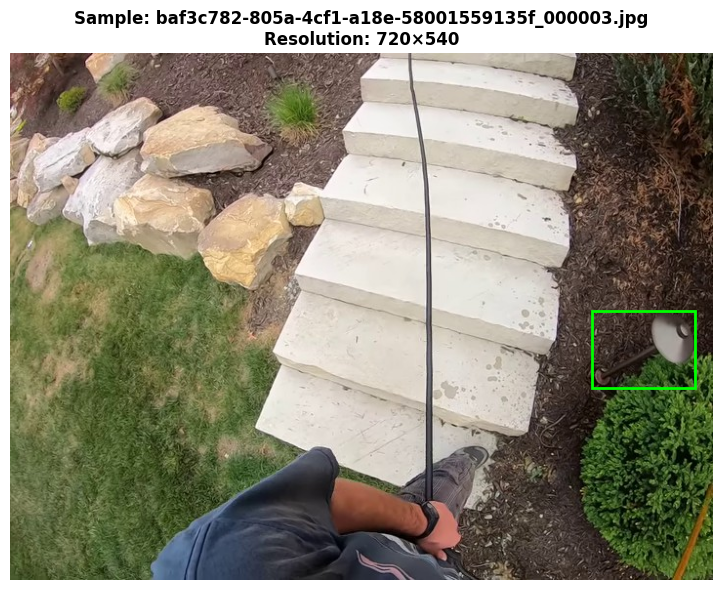

In [ ]:
# Quick sanity check — visualize one sample with its label
sample_img  = list((DATA_DIR / "train" / "images_flat").glob("*.jpg"))[0]
sample_lbl  = (DATA_DIR / "train" / "labels_flat" / sample_img.stem).with_suffix(".txt")

img  = np.array(Image.open(sample_img))
h, w = img.shape[:2]

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.imshow(img)

if sample_lbl.exists():
    for line in sample_lbl.read_text().strip().split("\n"):
        cls, cx, cy, bw, bh = map(float, line.split())
        x1 = (cx - bw/2) * w
        y1 = (cy - bh/2) * h
        rect = patches.Rectangle(
            (x1, y1), bw*w, bh*h,
            linewidth=2, edgecolor="lime", facecolor="none"
        )
        ax.add_patch(rect)

ax.set_title(f"Sample: {sample_img.name}\nResolution: {w}×{h}", fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

## YOLO

In [ ]:
yolo_pretrained = YOLO(YOLO_MODEL)
print(f"Loaded: {YOLO_MODEL}")
print(f"COCO classes: {len(yolo_pretrained.names)}")

Loaded: yolov8s.pt
COCO classes: 80


In [ ]:
def yolo_zero_shot_eval(model, img_dir, lbl_dir, conf=CONF_THRESHOLD,
                         iou_thresh=IOU_THRESHOLD, max_samples=2000):
    """
    Zero-shot evaluation:
    - Run pretrained COCO model on val frames
    - Merge all predicted boxes regardless of class (class-agnostic)
    - Compute IoU against ground truth boxes
    - Report mAP@0.5 and mAP@0.5:0.95
    """
    img_paths = list(img_dir.glob("*.jpg"))[:max_samples]

    all_pred_boxes  = []   # [x1,y1,x2,y2,conf]
    all_gt_boxes    = []   # [x1,y1,x2,y2]
    all_image_ids   = []

    for img_id, img_path in enumerate(tqdm(img_paths, desc="Zero-shot inference")):
        lbl_path = (lbl_dir / img_path.stem).with_suffix(".txt")
        if not lbl_path.exists():
            continue

        # Ground truth boxes
        img  = Image.open(img_path)
        w, h = img.size
        gt_boxes = []
        for line in lbl_path.read_text().strip().split("\n"):
            if not line.strip():
                continue
            _, cx, cy, bw, bh = map(float, line.split())
            x1 = (cx - bw/2) * w
            y1 = (cy - bh/2) * h
            x2 = (cx + bw/2) * w
            y2 = (cy + bh/2) * h
            gt_boxes.append([x1, y1, x2, y2])

        # Predictions — class-agnostic: keep all boxes above conf threshold
        results = model.predict(str(img_path), conf=conf, verbose=False)[0]
        pred_boxes = []
        if results.boxes is not None and len(results.boxes):
            for box in results.boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                confidence      = box.conf[0].item()
                pred_boxes.append([x1, y1, x2, y2, confidence])

        all_gt_boxes.append(gt_boxes)
        all_pred_boxes.append(pred_boxes)
        all_image_ids.append(img_id)

    return compute_map(all_pred_boxes, all_gt_boxes)


def compute_iou(box1, box2):
    """Compute IoU between two [x1,y1,x2,y2] boxes."""
    xi1 = max(box1[0], box2[0])
    yi1 = max(box1[1], box2[1])
    xi2 = min(box1[2], box2[2])
    yi2 = min(box1[3], box2[3])
    inter = max(0, xi2-xi1) * max(0, yi2-yi1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0


def compute_map(all_preds, all_gts, iou_thresholds=None):
    """
    Compute mAP@0.5 and mAP@0.5:0.95 for single-class detection.
    all_preds: list of [[x1,y1,x2,y2,conf], ...] per image
    all_gts  : list of [[x1,y1,x2,y2], ...] per image
    """
    if iou_thresholds is None:
        iou_thresholds = np.arange(0.5, 1.0, 0.05)

    aps = []
    for iou_thresh in iou_thresholds:
        tp_list, fp_list, conf_list = [], [], []
        n_gt = sum(len(g) for g in all_gts)

        for preds, gts in zip(all_preds, all_gts):
            if not preds:
                continue
            preds_sorted = sorted(preds, key=lambda x: x[4], reverse=True)
            matched = set()
            for pred in preds_sorted:
                conf_list.append(pred[4])
                best_iou, best_idx = 0, -1
                for j, gt in enumerate(gts):
                    iou = compute_iou(pred[:4], gt)
                    if iou > best_iou:
                        best_iou, best_idx = iou, j
                if best_iou >= iou_thresh and best_idx not in matched:
                    tp_list.append(1)
                    fp_list.append(0)
                    matched.add(best_idx)
                else:
                    tp_list.append(0)
                    fp_list.append(1)

        if not conf_list:
            aps.append(0.0)
            continue

        # Sort by confidence
        order = np.argsort(conf_list)[::-1]
        tp_cum = np.cumsum(np.array(tp_list)[order])
        fp_cum = np.cumsum(np.array(fp_list)[order])
        precision = tp_cum / (tp_cum + fp_cum + 1e-8)
        recall    = tp_cum / (n_gt + 1e-8)

        # Compute AP using 11-point interpolation
        ap = 0.0
        for thr in np.linspace(0, 1, 11):
            p = precision[recall >= thr].max() if (recall >= thr).any() else 0
            ap += p / 11
        aps.append(ap)

    return {
        "mAP@0.5"     : aps[0],
        "mAP@0.5:0.95": np.mean(aps),
        "per_iou_ap"  : dict(zip(iou_thresholds.round(2), aps))
    }

print("Evaluation functions defined.")

Evaluation functions defined.


In [ ]:
# Run zero-shot evaluation
val_img_dir = DATA_DIR / "val" / "images_flat"
val_lbl_dir = DATA_DIR / "val" / "labels_flat"

print("Running YOLOv8s zero-shot evaluation...")
yolo_zeroshot_results = yolo_zero_shot_eval(
    yolo_pretrained, val_img_dir, val_lbl_dir
)

print("YOLOv8s Zero-Shot Results")
print(f"  mAP@0.5      : {yolo_zeroshot_results['mAP@0.5']:.4f}")
print(f"  mAP@0.5:0.95 : {yolo_zeroshot_results['mAP@0.5:0.95']:.4f}")

Running YOLOv8s zero-shot evaluation...


Zero-shot inference:   0%|          | 0/2000 [00:00<?, ?it/s]

YOLOv8s Zero-Shot Results
  mAP@0.5      : 0.0104
  mAP@0.5:0.95 : 0.0085


## YOLO Fine Tune

In [ ]:
os.rename(DATA_DIR / "train" / "images_flat", DATA_DIR / "train" / "images_train_flat")
os.rename(DATA_DIR / "train" / "labels_flat", DATA_DIR / "train" / "labels_train_flat")
os.rename(DATA_DIR / "val"   / "images_flat", DATA_DIR / "val"   / "images_val_flat")
os.rename(DATA_DIR / "val"   / "labels_flat", DATA_DIR / "val"   / "labels_val_flat")

In [ ]:
# Move labels into the images directory
# YOLO will find them right next to the images

train_lbl_dir = DATA_DIR / "train" / "labels_train_flat"
train_img_dir = DATA_DIR / "train" / "images_train_flat"

print("Moving train labels into images directory...")
for lbl in tqdm(list(train_lbl_dir.glob("*.txt"))):
    dst = train_img_dir / lbl.name
    if not dst.exists():
        os.rename(lbl, dst)

val_lbl_dir = DATA_DIR / "val" / "labels_val_flat"
val_img_dir = DATA_DIR / "val" / "images_val_flat"

print("Moving val labels into images directory...")
for lbl in tqdm(list(val_lbl_dir.glob("*.txt"))):
    dst = val_img_dir / lbl.name
    if not dst.exists():
        os.rename(lbl, dst)

print("Done.")

Moving train labels into images directory...


  0%|          | 0/184332 [00:00<?, ?it/s]

Moving val labels into images directory...


  0%|          | 0/61874 [00:00<?, ?it/s]

Done.


In [ ]:
yaml_content = f"""path: {DATA_DIR}
train: train/images_train_flat
val: val/images_val_flat

nc: 1
names: ['object']
"""
dataset_yaml.write_text(yaml_content)

116

In [ ]:
# import glob

# cache_files = glob.glob(str(DATA_DIR) + "/**/*.cache", recursive=True)
# for f in cache_files:
#     os.remove(f)
#     print(f"Deleted: {f}")

Deleted: /content/egorecall_detection/train/images_train_flat.cache
Deleted: /content/egorecall_detection/val/images_val_flat.cache


In [ ]:
print(dataset_yaml.read_text())

path: /content/egorecall_detection
train: train/images_train_flat
val: val/images_val_flat

nc: 1
names: ['object']



In [ ]:
# Check labels are now in the images directory
train_img_dir = DATA_DIR / "train" / "images_train_flat"
jpgs = list(train_img_dir.glob("*.jpg"))
txts = list(train_img_dir.glob("*.txt"))
print(f"Images in dir : {len(jpgs):,}")
print(f"Labels in dir : {len(txts):,}")

# Sample check
sample = txts[0]
print(f"\nSample label  : {sample.name}")
print(f"Content       : {sample.read_text().strip()}")

Images in dir : 184,332
Labels in dir : 184,332

Sample label  : 4925ef3e-26f4-4b7e-b0cd-fd4c0f67f5eb_000972.txt
Content       : 0 0.588018 0.042542 0.100911 0.084028


In [ ]:
# import shutil

# for i in range(1, 9):
#     path = Path(f"/content/results/detection/yolov8s_finetune-{i}")
#     if path.exists():
#         shutil.rmtree(path)
#         print(f"Removed: {path}")

# # Also remove the original incomplete one
# path = Path("/content/results/detection/yolov8s_finetune")
# if path.exists():
#     shutil.rmtree(path)
#     print(f"Removed: {path}")

In [ ]:
# ── Check for existing checkpoint to resume from ───────────────────────────
last_pt = RESULTS_DIR / "yolov8s_finetune" / "weights" / "last.pt"

if last_pt.exists():
    print(f"Resuming from checkpoint: {last_pt}")
    yolo_finetune = YOLO(str(last_pt))
    yolo_train_results = yolo_finetune.train(resume=True)
else:
    print("Starting fresh training run...")
    yolo_finetune = YOLO(YOLO_MODEL)
    yolo_train_results = yolo_finetune.train(
        data          = str(dataset_yaml),
        epochs        = 15,
        imgsz         = 320,
        batch         = YOLO_BATCH_SIZE,
        device        = DEVICE,
        project       = str(RESULTS_DIR),
        name          = "yolov8s_finetune",
        lr0           = 0.01,
        lrf           = 0.01,
        warmup_epochs = 3,
        hsv_h         = 0.015,
        hsv_s         = 0.7,
        hsv_v         = 0.4,
        flipud        = 0.0,
        fliplr        = 0.5,
        mosaic        = 1.0,
        save_period   = 1,     # ← save last.pt every epoch
        plots         = True,
        verbose       = True,
    )

Starting fresh training run...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/egorecall_detection/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_finetune-2, nbs=64, nms=False, opset=None, optimize=Fa

In [41]:
saved_model = "/content/drive/MyDrive/School_Uchicago/Computer_Vision/Project/yolov8s_finetune-2/weights/best.pt"

In [ ]:
# !mv /content/results/detection/yolov8s_finetune-2/ /content/drive/MyDrive/School_Uchicago/Computer_Vision/Project/
# !ls /content/drive/MyDrive/School_Uchicago/Computer_Vision/Project/yolov8s_finetune-2/weights/

In [43]:
# Evaluate fine-tuned YOLOv8s
best_yolo_path = RESULTS_DIR / "yolov8s_finetune-2" / "weights" / "best.pt"
best_yolo_path = Path(saved_model)
print(f"Weights exist: {best_yolo_path.exists()}")

yolo_finetuned = YOLO(str(best_yolo_path))

# Use built-in val — correct for fine-tuned model
val_metrics = yolo_finetuned.val(data=str(dataset_yaml))

print("\nYOLOv8s Fine-Tuned Results")
print(f"  mAP@0.5      : {val_metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95 : {val_metrics.box.map:.4f}")

Weights exist: True
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 33.4±13.6 MB/s, size: 66.2 KB)
val: Scanning /content/egorecall_detection/val/images_val_flat... 61874 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 61874/61874 481.3it/s 2:09
val: New cache created: /content/egorecall_detection/val/images_val_flat.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3868/3868 9.3it/s 6:56
                   all      61874      67539      0.192      0.158      0.085     0.0472
Speed: 0.2ms preprocess, 1.8ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/val

YOLOv8s Fine-Tuned Results
  mAP@0.5      : 0.0850
  mAP@0.5:0.95 : 0.0472


In [ ]:
yolo_val_metrics = yolo_finetuned.val(data=str(dataset_yaml))
print(f"Built-in val mAP@0.5      : {yolo_val_metrics.box.map50:.4f}")
print(f"Built-in val mAP@0.5:0.95 : {yolo_val_metrics.box.map:.4f}")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 39.2±17.6 MB/s, size: 85.6 KB)
val: Scanning /content/egorecall_detection/val/images_val_flat.cache... 61874 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 61874/61874 11.3Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3868/3868 8.3it/s 7:45
                   all      61874      67539      0.192      0.158      0.085     0.0472
Speed: 0.3ms preprocess, 2.0ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val
Built-in val mAP@0.5      : 0.0850
Built-in val mAP@0.5:0.95 : 0.0472


## Results Comparison

In [45]:
results = {
    "Model": ["YOLOv8s (zero-shot)", "YOLOv8s (fine-tuned)"],
    "mAP@0.5": [
        yolo_zeroshot_results["mAP@0.5"],
        val_metrics.box.map50,
    ],
    "mAP@0.5:0.95": [
        yolo_zeroshot_results["mAP@0.5:0.95"],
        val_metrics.box.map,
    ],
}
results_df = pd.DataFrame(results)
results_df["mAP@0.5"]      = results_df["mAP@0.5"].round(4)
results_df["mAP@0.5:0.95"] = results_df["mAP@0.5:0.95"].round(4)
print(results_df.to_string(index=False))

               Model  mAP@0.5  mAP@0.5:0.95
 YOLOv8s (zero-shot)   0.0104        0.0085
YOLOv8s (fine-tuned)   0.0850        0.0472


**Results analysis**

The first run of the YOLO model led to a 6.8x improvement over the zero-shot just from fine-tuning on domain specific data. The absolute number is low, however; this is expected given:
1. imgsz=320 — small input resolution hurts small object detection
2. Only 15 epochs — likely still improving
3. Objects at median 1.9% normalized area are genuinely hard

The domain gap between COCO and egocentric video is severe (zero-shot near zero), but fine-tuning recovers significant performance even with a relatively short training run.

This motivates the fine-tuning approach and sets up a clean comparison with DETR.

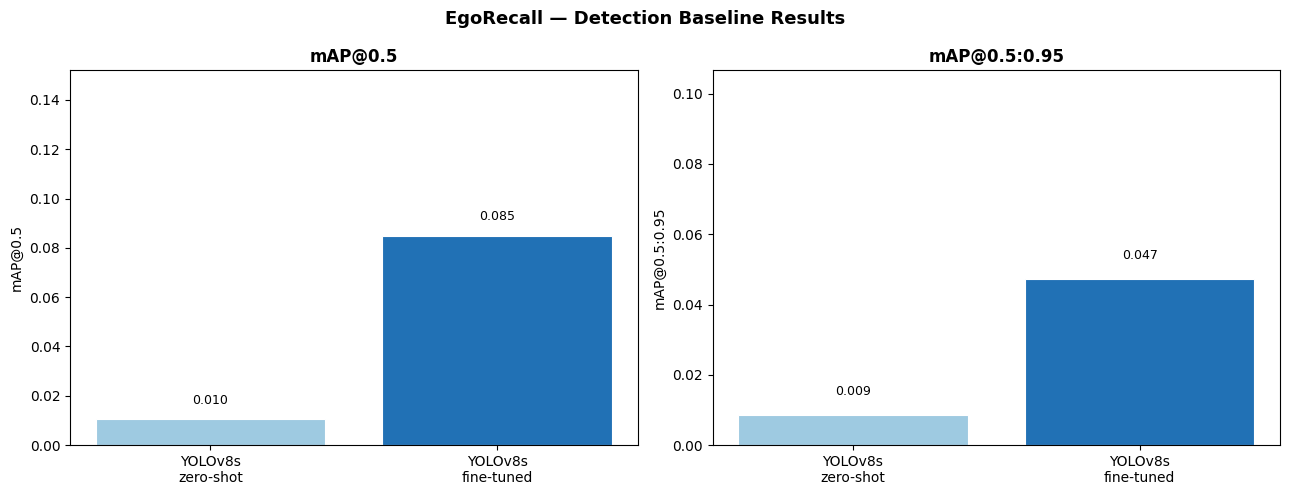

In [46]:
# ── Bar chart comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#9ecae1", "#2171b5", "#fcae91", "#cb181d"]
models = ["YOLOv8s\nzero-shot", "YOLOv8s\nfine-tuned"]
x = np.arange(len(models))

for ax, metric in zip(axes, ["mAP@0.5", "mAP@0.5:0.95"]):
    vals = results_df[metric].values
    bars = ax.bar(x, vals, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10)
    ax.set_ylabel(metric)
    ax.set_title(metric, fontweight="bold")
    ax.set_ylim(0, max(vals) * 1.2 + 0.05)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("EgoRecall — Detection Baseline Results", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "detection_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

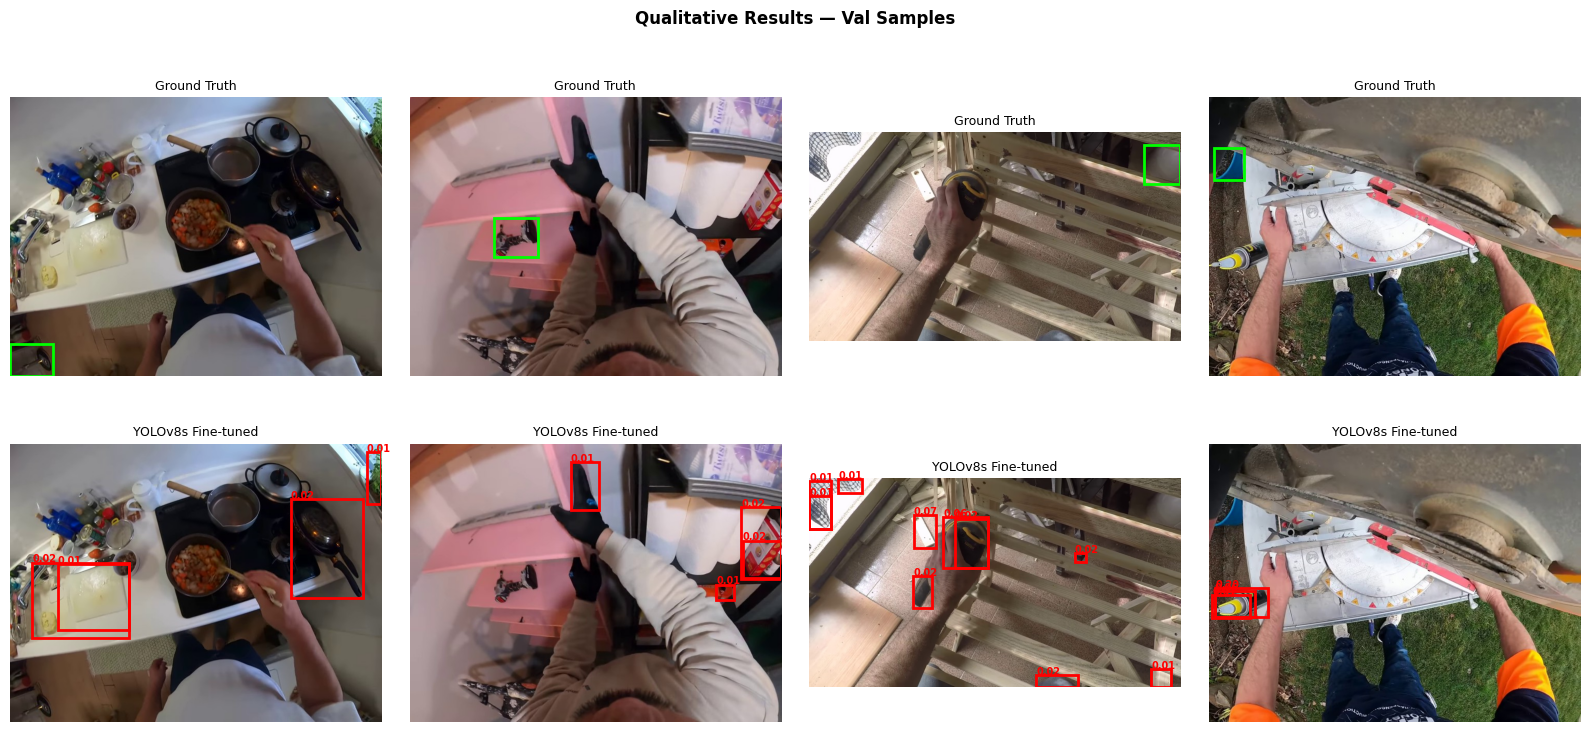

In [49]:
# ── Qualitative: visualize predictions on sample val images ───────────────
sample_paths = list(val_img_dir.glob("*.jpg"))[:4]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, img_path in enumerate(sample_paths):
    lbl_path = img_path.with_suffix(".txt")
    img      = np.array(Image.open(img_path))
    h, w     = img.shape[:2]

    # Ground truth
    axes[0, i].imshow(img)
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().split("\n"):
            if not line.strip(): continue
            _, cx, cy, bw, bh = map(float, line.split())
            rect = patches.Rectangle(
                ((cx-bw/2)*w, (cy-bh/2)*h), bw*w, bh*h,
                linewidth=2, edgecolor="lime", facecolor="none"
            )
            axes[0, i].add_patch(rect)
    axes[0, i].set_title("Ground Truth", fontsize=9)
    axes[0, i].axis("off")

    # YOLOv8 fine-tuned predictions
    axes[1, i].imshow(img)
    # results = yolo_finetuned.predict(str(img_path), conf=0.25, verbose=False)[0]
    results = yolo_finetuned.predict(str(img_path), conf=0.01, verbose=False)[0]
    if results.boxes is not None:
        for box in results.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf = box.conf[0].item()
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="red", facecolor="none"
            )
            axes[1, i].add_patch(rect)
            axes[1, i].text(x1, y1-2, f"{conf:.2f}",
                            color="red", fontsize=7, fontweight="bold")
    axes[1, i].set_title("YOLOv8s Fine-tuned", fontsize=9)
    axes[1, i].axis("off")

plt.suptitle("Qualitative Results — Val Samples", fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "qualitative_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

In [50]:
sample = list(val_img_dir.glob("*.jpg"))[0]
results = yolo_finetuned.predict(str(sample), conf=0.01, verbose=False)[0]
print(f"Boxes predicted : {len(results.boxes) if results.boxes else 0}")
if results.boxes is not None and len(results.boxes):
    for box in results.boxes:
        print(f"  conf={box.conf[0].item():.4f}  xyxy={box.xyxy[0].tolist()}")

Boxes predicted : 4
  conf=0.0166  xyxy=[543.6991577148438, 106.82563018798828, 683.906005859375, 299.68048095703125]
  conf=0.0150  xyxy=[43.11174011230469, 230.0784912109375, 230.21749877929688, 376.683349609375]
  conf=0.0128  xyxy=[691.4547119140625, 16.393077850341797, 720.0, 116.4266357421875]
  conf=0.0119  xyxy=[92.09247589111328, 233.65316772460938, 231.32064819335938, 361.416748046875]


## Potential Improvements — YOLOv8s

### Training
- **More epochs**: currently 10 epochs, likely still improving. Resume from `last.pt`
  and train to 20-30 epochs for meaningful convergence
- **Larger image size**: `imgsz=320` was chosen for speed. Increasing to `imgsz=640`
  will improve small object detection significantly given median object area of 1.9%
- **YOLOv8m or YOLOv8l**: larger backbone may capture more detail for small objects
  at the cost of training time

### Confidence Threshold
- Current predictions only appear at `conf=0.01`:  model is detecting but with low
  confidence. This is expected for 10 epochs on small objects
- After more epochs, revisit the threshold: `conf=0.25` should become viable

### Data
- **Full resolution source videos**:  current frames are 720×540 (2× downscaled from
  annotation space). If original 1440×1080 videos are accessible, retraining would
  significantly improve small object detection
- **Data augmentation tuning**:  current augmentation is light. Could experiment with
  more aggressive scale augmentation to simulate objects at different distances

### Evaluation
- Current mAP computed on full val set (61,874 frames) at `imgsz=320`
- Re-evaluate at `imgsz=640` after retraining for a fair comparison with DETR
  which uses its own input resolution

### Comparison Note
- DETR is trained on a 200-clip subset (~18K frames) vs YOLOv8 on full dataset (184K)
- For a fair comparison, retrain both on the same subset or evaluate YOLOv8 on the
  same 50-clip val subset used for DETR